# Realistic synthetic phenopackets with a VAE — first results

**TL;DR.** We want synthetic patient cases to benchmark Exomiser reranking that are
(a) *realistic* and (b) *novel* (so an LLM can't just look the answer up). The usual tool
(phenotype2phenopacket) picks symptoms **independently**, which breaks the way real symptoms
*co-occur*. We trained a small **conditional VAE** on real cases (Phenopacket Store) and show it
produces cases that are **harder to tell apart from real ones** than two simpler baselines, and
that are **less similar to the training data than real cases are to each other** (i.e. realistic
without memorizing).

This notebook rebuilds the whole pipeline end-to-end so you can run and inspect every step.

> Scope note (please read before defending it): the realism here is measured on **pairwise
> symptom co-occurrence**. Higher-order structure and whether these cases make a genuinely
> *hard-but-fair* Exomiser benchmark are **not yet** tested — see *Caveats* at the end.

## 0. Setup & data location
We read the Phenopacket Store bundle that the `exomiser-rerank-benchmark` repo already
downloads. Point `STORE_DIR` at your copy if it lives elsewhere.

In [1]:
import os, glob, json, math, random, collections, statistics as st
from pathlib import Path
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

BENCH = Path(os.environ.get("SYNTHVAE_BENCH_REPO", Path.home()/"PythonProject"/"exomiser-rerank-benchmark"))
STORE_DIR = Path(os.environ.get("SYNTHVAE_STORE_DIR", BENCH/"data"/"ppkts"))
GENES_TO_DISEASE = Path(os.environ.get("SYNTHVAE_GENES_TO_DISEASE", BENCH/"data"/"genes_to_disease.txt"))
random.seed(0); np.random.seed(0); torch.manual_seed(0)
print("store:", STORE_DIR, "exists:", STORE_DIR.exists())

store: /Users/jtr4v/PythonProject/exomiser-rerank-benchmark/data/ppkts exists: True


## 1. Load the real cases
Each phenopacket becomes a **`Case`**: its disease (OMIM id), its causal gene, and the set of
observed HPO symptom terms. We keep only diseases with a **single causal gene** (so the
"right answer" is unambiguous) and at least **N cases** (so there's something to learn).

In [2]:
from dataclasses import dataclass

@dataclass(frozen=True)
class Case:
    case_id: str; omim: str; gene: str; terms: tuple

def _extract(p):
    omims=[d.get("term",{}).get("id") for d in (p.get("diseases") or [])
           if str(d.get("term",{}).get("id")).startswith("OMIM")]
    genes=set()
    for it in p.get("interpretations") or []:
        for g in it.get("diagnosis",{}).get("genomicInterpretations") or []:
            sym=(((g.get("variantInterpretation") or {}).get("variationDescriptor") or {})
                 .get("geneContext",{}).get("symbol"))
            if sym: genes.add(sym)
    hpo=sorted({f.get("type",{}).get("id") for f in (p.get("phenotypicFeatures") or [])
                if not f.get("excluded") and f.get("type",{}).get("id")})
    return omims, genes, hpo

def load_store_cases():
    out=[]
    for fp in glob.glob(str(STORE_DIR/"**"/"*.json"), recursive=True):
        try: p=json.loads(Path(fp).read_text())
        except Exception: continue
        omims,genes,hpo=_extract(p)
        if not omims or len(genes)!=1 or not hpo: continue
        gene=next(iter(genes))
        for om in omims: out.append(Case(Path(fp).stem, om, gene, tuple(hpo)))
    return out

def load_g2d():
    import csv; g2d=collections.defaultdict(set)
    if GENES_TO_DISEASE.exists():
        for row in csv.DictReader(GENES_TO_DISEASE.open(), delimiter="\t"):
            g2d[row["disease_id"]].add(row["gene_symbol"])
    return g2d

def build_corpus(min_cases=20, require_single_g2d=True):
    cases=load_store_cases()
    byd=collections.defaultdict(list); genes=collections.defaultdict(set)
    for c in cases: byd[c.omim].append(c); genes[c.omim].add(c.gene)
    g2d=load_g2d() if require_single_g2d else {}
    def ok(om):
        return (len(byd[om])>=min_cases and len(genes[om])==1
                and (not require_single_g2d or len(g2d.get(om,set()))==1))
    return [c for om in byd if ok(om) for c in byd[om]]

cases = build_corpus(min_cases=20)
print(f"eligible: {len({c.omim for c in cases})} diseases, {len(cases)} cases, "
      f"{len({c.gene for c in cases})} genes")
sizes=[len(c.terms) for c in cases]
print(f"profile size (symptoms/case): median={int(np.median(sizes))} mean={np.mean(sizes):.1f} max={max(sizes)}")

eligible: 99 diseases, 5888 cases, 89 genes
profile size (symptoms/case): median=7 mean=7.8 max=66


**Real cases are small** — a typical case has only ~7 symptoms. So "realistic" is mostly
about *which* ~7 symptoms appear, and which ones appear *together*.

## 2. The premise: do real symptoms actually cluster?
phenotype2phenopacket assumes symptoms are independent. Is that wrong? For each disease we
compare how often symptom *pairs* co-occur vs. what you'd expect if they were independent
(the `phi` correlation), and compare the real result to a **shuffled** version that destroys
co-occurrence but keeps each symptom's frequency. If real >> shuffled, the structure is real.

In [3]:
def strong_pair_rate(sets_):
    n=len(sets_); cnt=collections.Counter(t for s in sets_ for t in s)
    terms=[t for t,k in cnt.items() if 3<=k<=n-3]
    if len(terms)<2: return (0,0)
    cols={t:[1 if t in s else 0 for s in sets_] for t in terms}
    sums={t:sum(cols[t]) for t in terms}; pairs=strong=0
    for i in range(len(terms)):
        for j in range(i+1,len(terms)):
            a,b=terms[i],terms[j]; na,nb=sums[a],sums[b]
            n11=sum(1 for k in range(n) if cols[a][k] and cols[b][k])
            n10=na-n11; n01=nb-n11; n00=n-n11-n10-n01
            den=math.sqrt(na*nb*(n-na)*(n-nb))
            if den==0: continue
            phi=(n11*n00-n10*n01)/den; pairs+=1; strong+= abs(phi)>=0.3
    return pairs,strong

byd=collections.defaultdict(list)
for c in cases: byd[c.omim].append(set(c.terms))
obs_p=obs_s=nul_p=nul_s=0
for om,ss in byd.items():
    p,s=strong_pair_rate(ss); obs_p+=p; obs_s+=s
    for _ in range(2):
        # shuffle each term independently across cases (destroys co-occurrence, keeps frequency)
        terms=sorted({t for s in ss for t in s}); n=len(ss)
        col={t:[1 if t in s else 0 for s in ss] for t in terms}
        for t in terms: random.shuffle(col[t])
        shuffled=[set(t for t in terms if col[t][k]) for k in range(n)]
        p2,s2=strong_pair_rate(shuffled); nul_p+=p2; nul_s+=s2
print(f"observed strong-pair rate : {100*obs_s/obs_p:.1f}%")
print(f"shuffled (independence)   : {100*nul_s/nul_p:.1f}%")
print(f"--> real symptom pairs cluster ~{(obs_s/obs_p)/(nul_s/nul_p):.1f}x more than chance")

observed strong-pair rate : 11.8%
shuffled (independence)   : 3.4%
--> real symptom pairs cluster ~3.5x more than chance


So the premise holds: **real cases carry co-occurrence structure that independent draws miss.**
That's the thing a better generator should capture.

## 3. Train / holdout split
We hold out 20% of each disease's cases as a "real comparison set" the generators never see.
Per-disease so every disease appears in both.

In [4]:
def stratified_split(cases, frac=0.2, seed=0):
    rng=random.Random(seed); byd=collections.defaultdict(list)
    for c in cases: byd[c.omim].append(c)
    train=[]; hold=[]
    for om,g in sorted(byd.items()):
        gg=g[:]; rng.shuffle(gg); k=max(1,round(frac*len(gg)))
        hold+=gg[:k]; train+=gg[k:]
    return train,hold
train,holdout=stratified_split(cases)
print(f"train={len(train)}  holdout={len(holdout)}")

train=4715  holdout=1173


## 4. The measuring stick: a co-occurrence (PMI) detector
To judge realism we train a program to tell two piles of cases apart. A naive version (a
gradient-boosted classifier on raw symptom lists) is **too weak** — it scores barely above a
coin flip even for obviously-fake cases. Instead we use a detector aimed *directly* at
co-occurrence: from real training cases it learns each disease's **PMI** (pointwise mutual
information — how much more two symptoms co-occur than chance), then scores a case by the
average PMI of its symptom pairs. Real cases score high; independent-draw fakes score low.

We report its **AUC** (how well it separates an arm from real holdout): **~0.5 = indistinguishable**,
**higher = easy to spot as fake**. A good generator pushes its AUC down toward the *floor*
(real-vs-real).

In [5]:
class PMIDetector:
    def __init__(self, eps=1e-3): self.eps=eps; self.tab={}
    def fit(self, train):
        byd=collections.defaultdict(list)
        for c in train: byd[c.omim].append(set(c.terms))
        for om,ss in byd.items():
            uni=collections.Counter(); pair=collections.Counter()
            for s in ss:
                for t in s: uni[t]+=1
                sl=sorted(s)
                for i in range(len(sl)):
                    for j in range(i+1,len(sl)): pair[(sl[i],sl[j])]+=1
            self.tab[om]=(len(ss),uni,pair)
        return self
    def score(self,c):
        if c.omim not in self.tab: return 0.0
        n,uni,pair=self.tab[c.omim]; sl=sorted(set(c.terms)); v=[]
        for i in range(len(sl)):
            for j in range(i+1,len(sl)):
                a,b=sl[i],sl[j]; pa,pb=uni.get(a,0)/n,uni.get(b,0)/n
                if pa>0 and pb>0:
                    pab=pair.get((a,b),0)/n
                    v.append(math.log((pab+self.eps)/(pa*pb+self.eps)))
        return float(np.mean(v)) if v else 0.0
    def auc(self, real, other):
        br=collections.defaultdict(list); bo=collections.defaultdict(list)
        for c in real: br[c.omim].append(self.score(c))
        for c in other: bo[c.omim].append(self.score(c))
        ys=[]; ss=[]
        for om in br:
            r=br[om]; o=bo.get(om,[])
            if len(r)<4 or len(o)<4: continue
            ss.append(rankdata(np.r_[r,o])/(len(r)+len(o))); ys.append(np.r_[np.ones(len(r)),np.zeros(len(o))])
        return float(roc_auc_score(np.concatenate(ys), np.concatenate(ss)))

def floor_auc(det, holdout, seed=0):
    rng=random.Random(seed); bd=collections.defaultdict(list)
    for c in holdout: bd[c.omim].append(c)
    a=[]; b=[]
    for g in bd.values():
        gg=g[:]; rng.shuffle(gg); a+=gg[:len(gg)//2]; b+=gg[len(gg)//2:]
    return det.auc(a,b)

det=PMIDetector().fit(train)
print(f"FLOOR (real vs real) = {floor_auc(det,holdout):.3f}   <- should be ~0.5")

FLOOR (real vs real) = 0.532   <- should be ~0.5


## 5. The generators
Three arms, all generating cases for the **same diseases** with the **same per-disease counts**
as the real holdout (so the detector can't cheat on bookkeeping):

1. **Marginal** — phenotype2phenopacket's idea: pick symptoms independently by frequency.
2. **Chow-Liu** — the simplest model that respects *pairwise* structure (a dependency tree).
3. **VAE** — a small neural network that learns each disease's coherent presentations.

In [6]:
def disease_counts(cs): return dict(collections.Counter(c.omim for c in cs))

class MarginalSampler:
    def __init__(self, seed=0): self.rng=random.Random(seed)
    def fit(self, train):
        self.sizes={}; self.terms={}; self.w={}; self.gene={}
        byd=collections.defaultdict(list)
        for c in train: byd[c.omim].append(c)
        for om,g in byd.items():
            self.sizes[om]=[len(c.terms) for c in g]
            f=collections.Counter(t for c in g for t in c.terms)
            self.terms[om]=list(f); self.w[om]=[f[t] for t in self.terms[om]]; self.gene[om]=g[0].gene
        return self
    def one(self, om, i):
        size=min(self.rng.choice(self.sizes[om]), len(self.terms[om]))
        pw=list(zip(self.terms[om], self.w[om])); chosen=set()
        while len(chosen)<size and pw:
            ts,ws=zip(*pw); k=self.rng.choices(range(len(pw)),weights=ws,k=1)[0]
            chosen.add(pw[k][0]); pw.pop(k)
        return Case(f"marg_{om}_{i}", om, self.gene[om], tuple(sorted(chosen)))
    def cohort(self, counts):
        return [self.one(om,i) for om,n in counts.items() if om in self.sizes for i in range(n)]

In [7]:
class ChowLiu:
    def __init__(self, seed=0, min_count=2, a=1.0): self.rng=random.Random(seed); self.mc=min_count; self.a=a
    def fit(self, train):
        self.models={}; self.gene={}; byd=collections.defaultdict(list)
        for c in train: byd[c.omim].append(set(c.terms)); self.gene[c.omim]=c.gene
        for om,ss in byd.items(): self.models[om]=self._tree(ss)
        return self
    def _tree(self, ss):
        n=len(ss); cnt=collections.Counter(t for s in ss for t in s)
        terms=sorted(t for t,k in cnt.items() if k>=self.mc); m=len(terms); a=self.a
        if m==0: return {"terms":[]}
        idx={t:i for i,t in enumerate(terms)}
        X=np.zeros((n,m))
        for r,s in enumerate(ss):
            for t in s:
                if t in idx: X[r,idx[t]]=1
        p1=(X.sum(0)+a)/(n+2*a); J=X.T@X; mi=np.zeros((m,m))
        for i in range(m):
            for j in range(i+1,m):
                c11=J[i,j]; c10=X[:,i].sum()-c11; c01=X[:,j].sum()-c11; c00=n-c11-c10-c01
                jt=(np.array([c00,c01,c10,c11])+a)/(n+4*a)
                outer=np.array([(1-p1[i])*(1-p1[j]),(1-p1[i])*p1[j],p1[i]*(1-p1[j]),p1[i]*p1[j]])
                mi[i,j]=mi[j,i]=float((jt*np.log(jt/outer)).sum())
        parent=[-1]*m; intree=[False]*m; best=mi[0].copy(); bf=[0]*m; intree[0]=True; order=[0]
        for _ in range(m-1):
            cand=-1; cb=-1
            for v in range(m):
                if not intree[v] and best[v]>cb: cb=best[v]; cand=v
            if cand==-1: break
            intree[cand]=True; parent[cand]=bf[cand]; order.append(cand)
            for v in range(m):
                if not intree[v] and mi[cand,v]>best[v]: best[v]=mi[cand,v]; bf[v]=cand
        cond={}
        for ch in range(m):
            pa=parent[ch]
            if pa==-1: continue
            c11=float(J[ch,pa]); pn=float(X[:,pa].sum())
            cond[ch]=((float(X[:,ch].sum())-c11+a)/(n-pn+2*a), (c11+a)/(pn+2*a))
        return {"terms":terms,"order":order,"parent":parent,"proot":float(p1[order[0]]),"cond":cond}
    def one(self, om, i):
        m=self.models[om]; terms=m["terms"]
        if not terms: return Case(f"cl_{om}_{i}", om, self.gene[om], ())
        val=[0]*len(terms)
        for nd in m["order"]:
            pa=m["parent"][nd]; p=m["proot"] if pa==-1 else m["cond"][nd][val[pa]]
            val[nd]=1 if self.rng.random()<p else 0
        return Case(f"cl_{om}_{i}", om, self.gene[om], tuple(sorted(terms[i] for i in range(len(terms)) if val[i])))
    def cohort(self, counts):
        return [self.one(om,i) for om,n in counts.items() if om in self.models for i in range(n)]

In [8]:
class CVAE(nn.Module):
    def __init__(self, nt, nd, latent=16, hid=256, de=32):
        super().__init__()
        self.emb=nn.Embedding(nd,de)
        self.enc=nn.Sequential(nn.Linear(nt+de,hid),nn.ReLU(),nn.Linear(hid,hid),nn.ReLU())
        self.mu=nn.Linear(hid,latent); self.lv=nn.Linear(hid,latent)
        self.dec=nn.Sequential(nn.Linear(latent+de,hid),nn.ReLU(),nn.Linear(hid,hid),nn.ReLU(),nn.Linear(hid,nt))
    def forward(self,x,d):
        h=self.enc(torch.cat([x,self.emb(d)],1)); mu,lv=self.mu(h),self.lv(h)
        z=mu+torch.exp(0.5*lv)*torch.randn_like(lv)
        return self.dec(torch.cat([z,self.emb(d)],1)), mu, lv

class VAEGen:
    def __init__(self, latent=16, seed=0): self.latent=latent; self.seed=seed
    def fit(self, train, epochs=300, beta=0.5, warmup=50, free_bits=0.1):
        torch.manual_seed(self.seed); np.random.seed(self.seed)
        self.vocab=sorted({t for c in train for t in c.terms})
        self.dis=sorted({c.omim for c in train}); self.didx={d:i for i,d in enumerate(self.dis)}
        vi={t:i for i,t in enumerate(self.vocab)}
        X=np.zeros((len(train),len(self.vocab)),dtype="float32")
        for r,c in enumerate(train):
            for t in c.terms: X[r,vi[t]]=1
        X=torch.tensor(X); d=torch.tensor([self.didx[c.omim] for c in train])
        self.sizes=collections.defaultdict(list); self.gene={}
        for c in train: self.sizes[c.omim].append(len(c.terms)); self.gene[c.omim]=c.gene
        self.m=CVAE(len(self.vocab),len(self.dis),self.latent)
        opt=torch.optim.Adam(self.m.parameters(),1e-3); n=len(train)
        for ep in range(epochs):
            self.m.train(); perm=torch.randperm(n); kw=beta*min(1,ep/max(1,warmup))
            for i in range(0,n,256):
                idx=perm[i:i+256]; logits,mu,lv=self.m(X[idx],d[idx])
                rec=F.binary_cross_entropy_with_logits(logits,X[idx],reduction="none").sum(1).mean()
                kld=torch.clamp(-0.5*(1+lv-mu.pow(2)-lv.exp()),min=free_bits).sum(1).mean()
                loss=rec+kw*kld; opt.zero_grad(); loss.backward(); opt.step()
        return self
    @torch.no_grad()
    def cohort(self, counts):
        self.m.eval(); rng=random.Random(self.seed); out=[]
        for om,k in counts.items():
            if om not in self.didx or not self.sizes.get(om): continue
            d=torch.tensor([self.didx[om]]*k); probs=torch.sigmoid(self.m.dec(torch.cat([torch.randn(k,self.latent),self.m.emb(d)],1))).numpy()
            for i in range(k):
                p=probs[i]; size=min(rng.choice(self.sizes[om]), int((p>0).sum()))
                if size<=0: out.append(Case(f"vae_{om}_{i}",om,self.gene[om],())); continue
                ch=np.random.choice(len(self.vocab),size=size,replace=False,p=p/p.sum())
                out.append(Case(f"vae_{om}_{i}",om,self.gene[om],tuple(sorted(self.vocab[j] for j in ch))))
        return out

## 6. Head-to-head: which cases look most real?
Lower AUC = harder to tell from real = more realistic. The dashed line is the floor.

training VAE (~30s)...



FLOOR real-vs-real = 0.532
marginal (p2p-style)     0.745
Chow-Liu (pairwise)      0.609
VAE                      0.568


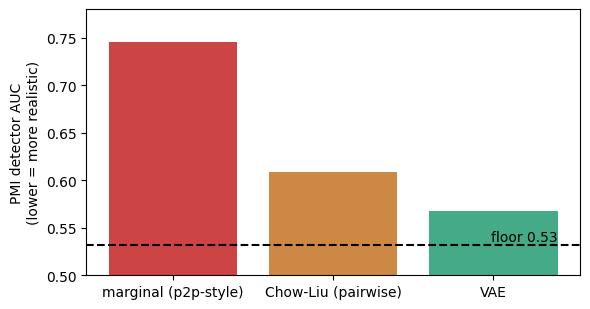

In [9]:
counts=disease_counts(holdout)
marg=MarginalSampler(0).fit(train).cohort(counts)
cl=ChowLiu(0).fit(train).cohort(counts)
print("training VAE (~30s)..."); vae=VAEGen(seed=0).fit(train); vcoh=vae.cohort(counts)

floor=floor_auc(det,holdout)
res={"marginal (p2p-style)":det.auc(holdout,marg),"Chow-Liu (pairwise)":det.auc(holdout,cl),"VAE":det.auc(holdout,vcoh)}
print(f"\nFLOOR real-vs-real = {floor:.3f}")
for k,v in res.items(): print(f"{k:24s} {v:.3f}")

fig,ax=plt.subplots(figsize=(6,3.2))
ax.bar(list(res),list(res.values()),color=["#c44","#c84","#4a8"])
ax.axhline(floor,ls="--",c="k"); ax.text(2.4,floor+.004,f"floor {floor:.2f}",ha="right")
ax.set_ylabel("PMI detector AUC\n(lower = more realistic)"); ax.set_ylim(0.5,0.78)
plt.tight_layout(); plt.show()

**Result:** the VAE is the hardest to distinguish from real cases and lands closest to the
floor — beating even the pairwise model, so it's capturing structure beyond simple symptom pairs.

## 7. Is the VAE just memorizing? (the anti-cheat check)
A generator that copies real cases would also look realistic but defeat the purpose. We measure
how similar each generated case is to its nearest **training** case (Jaccard overlap), and
compare to how similar **real holdout** cases are to training. The VAE should be **no more**
similar than real cases naturally are.

real holdout : mean sim=0.642  exact copies=21.9%
VAE          : mean sim=0.545  exact copies=9.2%


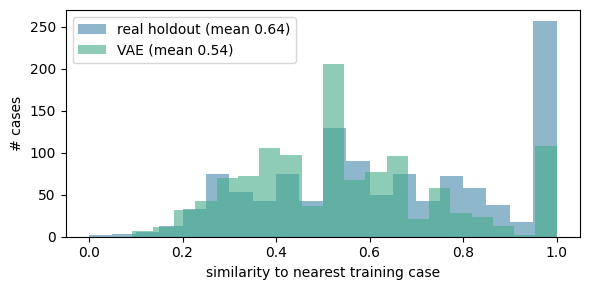

In [10]:
bytr=collections.defaultdict(list)
for c in train: bytr[c.omim].append(set(c.terms))
def jac(a,b): u=a|b; return len(a&b)/len(u) if u else 0.0
def nearest(cs):
    out=[]; exact=0
    for c in cs:
        s=set(c.terms); pool=bytr.get(c.omim,[])
        if not pool or not s: continue
        m=max(jac(s,t) for t in pool); out.append(m); exact+=(m==1.0)
    return np.array(out), exact
vh,eh=nearest(holdout); vv,ev=nearest(vcoh)
print(f"real holdout : mean sim={vh.mean():.3f}  exact copies={100*eh/len(vh):.1f}%")
print(f"VAE          : mean sim={vv.mean():.3f}  exact copies={100*ev/len(vv):.1f}%")

fig,ax=plt.subplots(figsize=(6,3))
ax.hist(vh,bins=20,alpha=.6,label=f"real holdout (mean {vh.mean():.2f})",color="#48a")
ax.hist(vv,bins=20,alpha=.6,label=f"VAE (mean {vv.mean():.2f})",color="#4a8")
ax.set_xlabel("similarity to nearest training case"); ax.set_ylabel("# cases"); ax.legend()
plt.tight_layout(); plt.show()

**Result:** the VAE's cases are *less* similar to training data than real cases are to each
other — so it's generating novel combinations, not copying. Good for the "can't look it up" goal.

## 8. Is it stable? (seeds & corpus size)
We rerun across random seeds and three minimum-case thresholds N.

In [11]:
print(f"{'N':>3} {'diseases':>8} | {'floor':>6} {'marginal':>8} {'ChowLiu':>8} | {'VAE mean':>9} {'sd':>5}")
for N in [20,30,50]:
    cs=build_corpus(min_cases=N); tr,ho=stratified_split(cs); d2=PMIDetector().fit(tr); ct=disease_counts(ho)
    fl=floor_auc(d2,ho)
    mg=d2.auc(ho,MarginalSampler(0).fit(tr).cohort(ct)); cz=d2.auc(ho,ChowLiu(0).fit(tr).cohort(ct))
    vs=[d2.auc(ho,VAEGen(seed=s).fit(tr).cohort(ct)) for s in [0,1]]
    print(f"{N:>3} {len({c.omim for c in cs}):>8} | {fl:>6.3f} {mg:>8.3f} {cz:>8.3f} | {st.mean(vs):>9.3f} {st.pstdev(vs):>5.3f}")

  N diseases |  floor marginal  ChowLiu |  VAE mean    sd


 20       99 |  0.532    0.745    0.609 |     0.576 0.008


 30       68 |  0.509    0.704    0.596 |     0.580 0.006


 50       37 |  0.460    0.686    0.583 |     0.568 0.008


**Result:** the VAE is seed-stable and beats both baselines at every N. (The floor gets noisy
at N=50 because few diseases remain — N=20 is the cleanest setting.)

## 9. What this shows — and what it does not (please read before defending)

**What we can claim:**
- Real cases have co-occurrence structure that independent draws miss (~3.6x over chance).
- By a calibrated, co-occurrence-sensitive detector, **VAE cases are harder to tell from real
  cases than two simpler baselines**, stably across seeds and corpus sizes.
- The VAE does this **without memorizing** — its cases are more novel than real cases are to each other.

**What we do NOT yet claim:**
- *Pairwise only.* Realism is measured on symptom **pairs**; higher-order structure and mode
  coverage are not yet checked (the VAE could, e.g., generate only the common subtype).
- *One metric.* We should add an independent second metric so the result doesn't rest on one ruler.
- *Benchmark utility untested.* We have **not** shown these cases make Exomiser reranking
  *hard-but-fair* — that is the most important next experiment.
- *Anti-cheat is indirect.* Lower training-overlap is encouraging but we haven't tested whether an
  LLM can still retrieve the diagnosis.
- Demographics and the causal variant are out of scope for this version.

**Open questions for you all:** Is the PMI detector a fair ruler? What second metric would convince
you? And what would "hard-but-fair for Exomiser" look like concretely?